# CoGames Autoresearch — Experiment Analysis

Analysis of autonomous RL experiment results from `results.tsv`.

Score is `composite_score` (higher = better, opposite of Karpathy's val_bpb).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('results.tsv', sep='\t')
df['composite_score'] = pd.to_numeric(df['composite_score'], errors='coerce')
df['mean_reward'] = pd.to_numeric(df['mean_reward'], errors='coerce')
df['status'] = df['status'].str.strip().str.lower()

# Deduplicate: keep first occurrence per commit (tsv has some dupe rows)
df = df.drop_duplicates(subset=['commit', 'status'], keep='first').reset_index(drop=True)

print(f'Total rows:  {len(df)}')
print(f'Columns:     {list(df.columns)}')
print(f'Status breakdown:')
print(df['status'].value_counts().to_string())
df.head(10)

Total rows:  52
Columns:     ['commit', 'composite_score', 'mean_reward', 'memory_gb', 'status', 'description']
Status breakdown:
status
keep       38
discard     9
crash       5


,commit,composite_score,mean_reward,memory_gb,status,description
0,ee360ae,0.000000,0.000000,0.0,crash,milestones_2 baseline
1,83479bb,0.000000,0.000000,0.0,crash,milestones_2 baseline
2,e107db6,0.000000,0.000000,0.0,crash,milestones_2 baseline
3,0198a04,0.498750,0.498750,0.0,keep,milestones_2 baseline
4,ac95561,0.048000,0.048000,0.0,keep,milestones_2:25 compounding factor
5,f88dfe1,-0.539687,-0.539687,0.0,crash,milestones_2 + credit (dense bootstrap)
6,62f1509,0.231389,0.231389,0.0,keep,milestones_2 ent_coef=0.05
7,3c0de34,0.048500,0.048500,0.0,keep,milestones_2:10 compounding
8,9a52625,0.025312,0.025312,0.0,keep,milestones_2 minibatch=2048
9,40671f8,0.073875,0.073875,0.0,keep,milestones_2 stateless policy


In [2]:
kept   = df[df['status'] == 'keep'].copy()
discard = df[df['status'] == 'discard'].copy()
crash  = df[df['status'] == 'crash'].copy()

n_decided = len(kept) + len(discard)
print(f'Keep rate:   {len(kept)}/{n_decided} = {len(kept)/n_decided:.1%}')
print(f'Crashes:     {len(crash)}')
print(f'Best score:  {kept["composite_score"].max():.4f}')
best_row = kept.loc[kept['composite_score'].idxmax()]
print(f'Best run:    {best_row["description"]}')
print(f'Best commit: {best_row["commit"]}')

Keep rate:   38/47 = 80.9%
Crashes:     5
Best score:  234.0031
Best run:    milestones + role_conditional + penalize_vibe_change + credit + scout
Best commit: 4ba6771


## Score Over Time

All experiments plotted. Green = kept, grey = discarded, red = crash. Step line shows the running best.

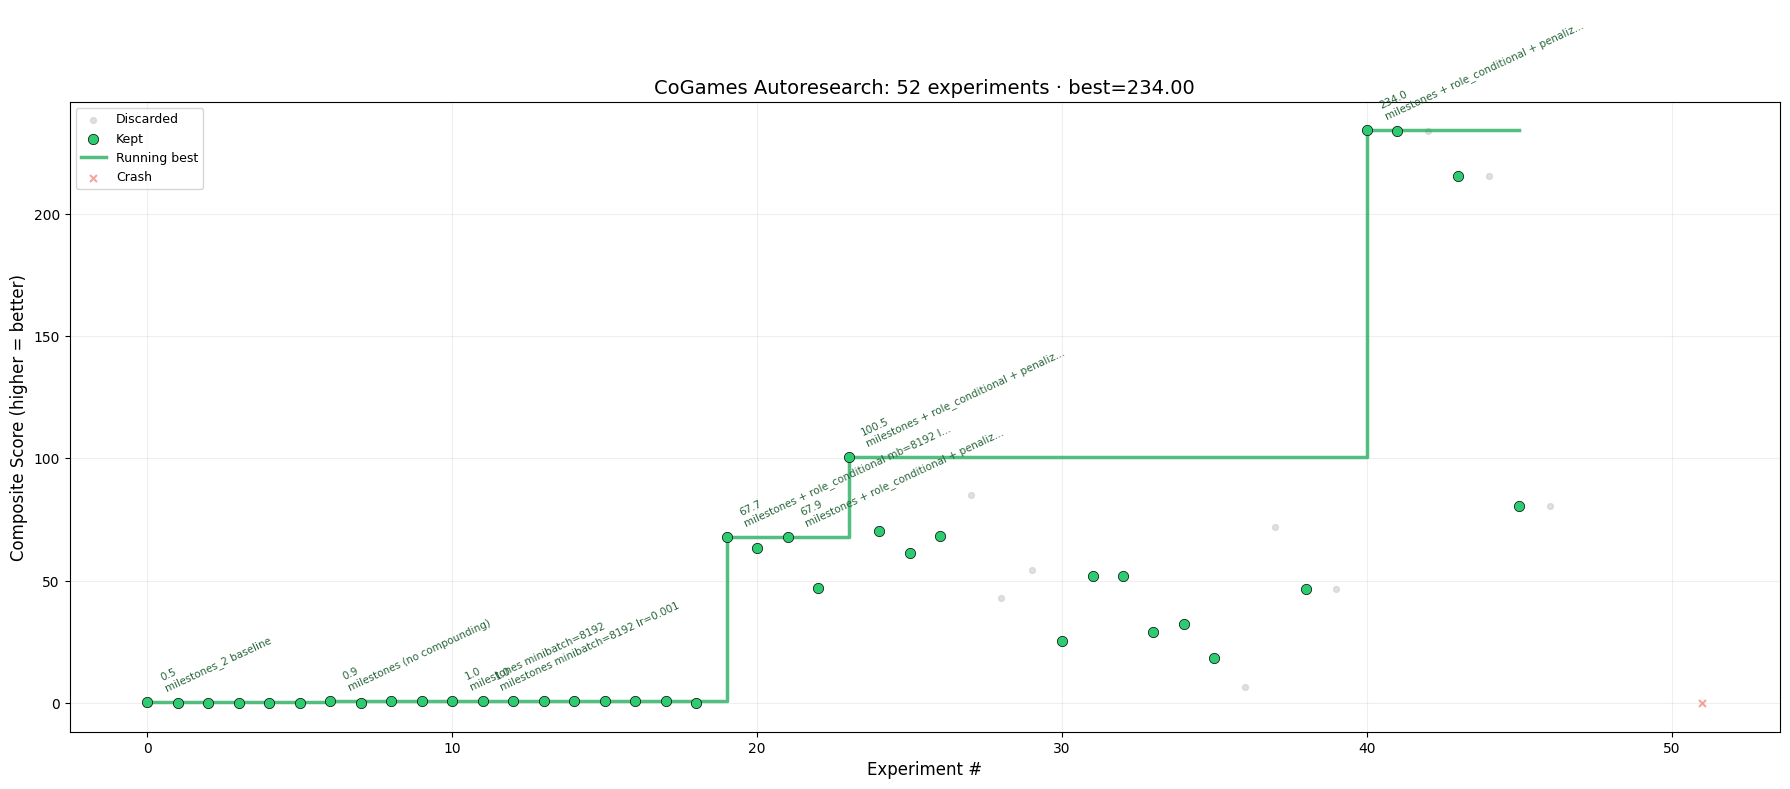

Saved to progress.png


In [3]:
fig, ax = plt.subplots(figsize=(18, 8))

# Drop crashes for the main plot, plot them separately at y=0
valid = df[df['status'] != 'crash'].reset_index(drop=True)

disc_v = valid[valid['status'] == 'discard']
kept_v = valid[valid['status'] == 'keep']

ax.scatter(disc_v.index, disc_v['composite_score'],
           c='#cccccc', s=18, alpha=0.6, zorder=2, label='Discarded')
ax.scatter(kept_v.index, kept_v['composite_score'],
           c='#2ecc71', s=55, zorder=4, label='Kept',
           edgecolors='black', linewidths=0.5)

# Running best (cummax since higher = better)
kept_mask = valid['status'] == 'keep'
kept_idx  = valid.index[kept_mask]
kept_scores = valid.loc[kept_mask, 'composite_score']
running_best = kept_scores.cummax()
ax.step(kept_idx, running_best, where='post',
        color='#27ae60', linewidth=2.5, alpha=0.8, zorder=3, label='Running best')

# Annotate only the NEW bests (when running_best actually improves)
prev_best = -np.inf
for idx, score in zip(kept_idx, kept_scores):
    if score > prev_best:
        desc = str(valid.loc[idx, 'description']).strip()
        if len(desc) > 42:
            desc = desc[:39] + '...'
        ax.annotate(f'{score:.1f}\n{desc}',
                    (idx, score),
                    textcoords='offset points',
                    xytext=(8, 6), fontsize=7.5,
                    color='#1a5c2e', alpha=0.95,
                    rotation=25, ha='left', va='bottom')
        prev_best = score

# Crash markers along x-axis
crash_x = df[df['status'] == 'crash'].index
ax.scatter(crash_x, [0]*len(crash_x),
           c='#e74c3c', s=25, marker='x', alpha=0.5, zorder=3, label='Crash')

ax.set_xlabel('Experiment #', fontsize=12)
ax.set_ylabel('Composite Score (higher = better)', fontsize=12)
ax.set_title(
    f'CoGames Autoresearch: {len(df)} experiments · best={kept["composite_score"].max():.2f}',
    fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('progress.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to progress.png')

## Top Improvements (ranked by delta over previous best)

In [4]:
# Only unique best-improvements: when running best actually moved
kept_sorted = kept.sort_index().copy()
kept_sorted['running_best'] = kept_sorted['composite_score'].cummax()
kept_sorted['prev_best'] = kept_sorted['running_best'].shift(1).fillna(0)
kept_sorted['delta'] = kept_sorted['running_best'] - kept_sorted['prev_best']
improvements = kept_sorted[kept_sorted['delta'] > 0].copy()

improvements_sorted = improvements.sort_values('delta', ascending=False)
print(f'{"Rank":>4}  {"Delta":>10}  {"Score":>10}  Description')
print('-' * 85)
for rank, (_, row) in enumerate(improvements_sorted.iterrows(), 1):
    print(f'{rank:4d}  {row["delta"]:+10.4f}  {row["composite_score"]:10.4f}  {row["description"]}')

Rank       Delta       Score  Description
-------------------------------------------------------------------------------------
   1   +133.4567    234.0031  milestones + role_conditional + penalize_vibe_change + credit + scout
   2    +66.6682     67.7140  milestones + role_conditional mb=8192 lr=0.001
   3    +32.6360    100.5464  milestones + role_conditional + penalize_vibe_change + credit
   4     +0.4988      0.4988  milestones_2 baseline
   5     +0.4473      0.9460  milestones (no compounding)
   6     +0.1964     67.9104  milestones + role_conditional + penalize_vibe_change
   7     +0.0780      1.0458  milestones minibatch=8192 lr=0.001
   8     +0.0217      0.9678  milestones minibatch=8192


## Reward Variant Impact

Which reward variants appear in the best runs?

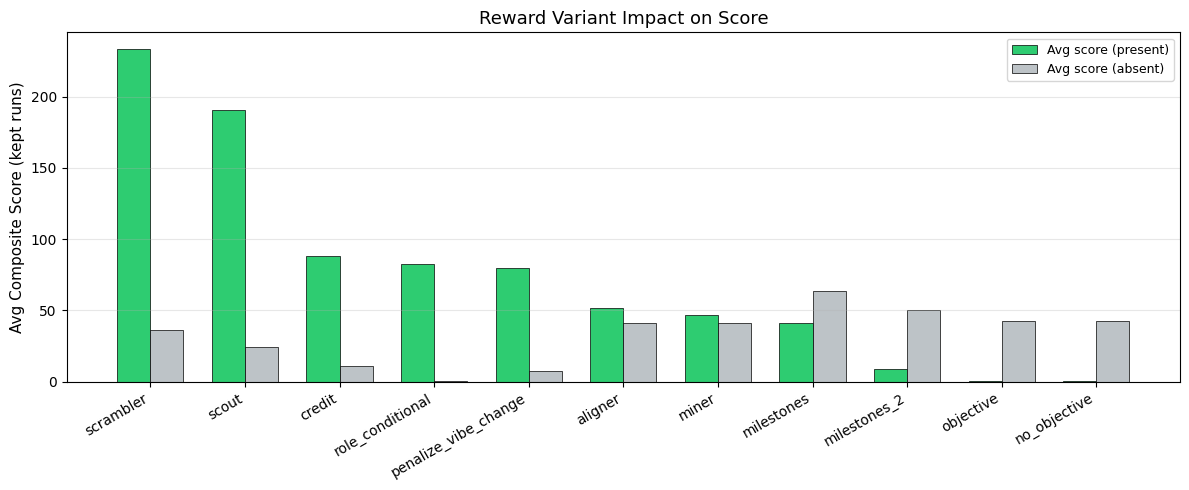

             variant  n_present  avg_score_present  max_score_present  avg_score_absent
           scrambler          1         233.584500         233.584500         36.284986
               scout          4         190.820810         234.003110         23.907228
              credit         15          87.916843         234.003110         11.190276
    role_conditional         19          82.346171         234.003110          0.607987
penalize_vibe_change         18          79.690529         234.003110          7.084974
             aligner          1          51.732724          51.732724         41.199899
               miner          1          46.660047          46.660047         41.336999
          milestones         37          40.887280         234.003110         63.299636
        milestones_2          8           8.904201          70.251280         50.163180
           objective          1           0.062500           0.062500         42.596392
        no_objective          1 

In [5]:
all_variants = ['milestones', 'milestones_2', 'role_conditional', 'penalize_vibe_change',
                'credit', 'scout', 'miner', 'aligner', 'scrambler', 'objective', 'no_objective']

# For each variant, compute avg score when present vs absent (kept runs only)
rows = []
for v in all_variants:
    present = kept[kept['description'].str.contains(v, na=False)]
    absent  = kept[~kept['description'].str.contains(v, na=False)]
    if len(present) == 0:
        continue
    rows.append({
        'variant': v,
        'n_present': len(present),
        'avg_score_present': present['composite_score'].mean(),
        'max_score_present': present['composite_score'].max(),
        'avg_score_absent':  absent['composite_score'].mean() if len(absent) > 0 else 0,
    })

vdf = pd.DataFrame(rows).sort_values('avg_score_present', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(vdf))
w = 0.35
ax.bar(x - w/2, vdf['avg_score_present'], w, label='Avg score (present)', color='#2ecc71', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, vdf['avg_score_absent'],  w, label='Avg score (absent)',  color='#bdc3c7', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(vdf['variant'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Avg Composite Score (kept runs)', fontsize=11)
ax.set_title('Reward Variant Impact on Score', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(vdf[['variant','n_present','avg_score_present','max_score_present','avg_score_absent']].to_string(index=False))

## Full Experiment Log (kept runs only)

In [6]:
print(f'{"#":>4}  {"Score":>10}  {"Commit":>8}  Description')
print('-' * 85)
for i, (_, row) in enumerate(kept.iterrows(), 1):
    print(f'{i:4d}  {row["composite_score"]:10.4f}  {row["commit"]:>8}  {row["description"]}')

   #       Score    Commit  Description
-------------------------------------------------------------------------------------
   1      0.4988   0198a04  milestones_2 baseline
   2      0.0480   ac95561  milestones_2:25 compounding factor
   3      0.2314   62f1509  milestones_2 ent_coef=0.05
   4      0.0485   3c0de34  milestones_2:10 compounding
   5      0.0253   9a52625  milestones_2 minibatch=2048
   6      0.0739   40671f8  milestones_2 stateless policy
   7      0.9460   70dd9bb  milestones (no compounding)
   8      0.0565   3c84727  milestones + milestones_2 stacked
   9      0.8659   940746e  milestones + penalize_vibe_change
  10      0.8620   d509d84  milestones lr=0.002
  11      0.9678   d8e48ff  milestones minibatch=8192
  12      1.0458   12fde24  milestones minibatch=8192 lr=0.001
  13      0.9702   bfb3785  milestones minibatch=8192 lr=0.0015
  14      1.0001   cde8255  milestones minibatch=16384 lr=0.001
  15      0.9697   42f6fc1  milestones mb=8192 lr=0.001 gamma=0